# Predicting Monthly Unit Sales with XGBoost

## 1. Project Overview

This project uses historical monthly sales data to analyze demand patterns and predict future unit sales. The analysis combines MySQL for data preparation and KPI calculations with Python for exploratory data analysis, feature engineering, machine-learning modeling, model evaluation, and future forecasting.

Four forecasting approaches were evaluated: Baseline, Linear Regression, Prophet, and XGBoost. XGBoost was selected as the final model based on its superior validation performance.

## 2. Business Problem

Accurate sales forecasting is essential for effective inventory planning, resource allocation, and demand management. However, fluctuations in monthly unit sales can make it difficult for businesses to anticipate future demand and make informed operational decisions.

The objective of this project is to analyze historical monthly unit sales, identify patterns such as seasonality and recent sales trends, and develop a forecasting model that can accurately predict future unit demand.

The analysis compares multiple forecasting approaches, including a baseline model, Linear Regression, Prophet, and XGBoost, using a chronological validation strategy. The best-performing model is then used to forecast monthly unit sales for August through December 2026.

The goal is to provide a reliable, data-driven estimate of future demand that can support inventory planning and business decision-making.

### Connecting mysql workbench and import libraries

In [1]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from datetime import timedelta
%matplotlib inline

In [3]:
!pip install pymysql

  Using cached pymysql-1.2.0-py3-none-any.whl.metadata (4.3 kB)
Using cached pymysql-1.2.0-py3-none-any.whl (45 kB)


In [ ]:
def get_connection():
    engine = create_engine(
        "mysql+pymysql://{user}:{password}@{host}/{database}")
    )
    return engine

In [ ]:
import os
from sqlalchemy import("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
host = os.getevn("MYSQL_HOST", "localhost")
database = os.getenv("MYSQL_DATABASE")

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}/{database}")

In [43]:
product_monthly_sales = pd.read_sql(
    "SELECT * FROM product_monthly_sales",
    engine
)

In [44]:
product_monthly_sales.head()

,product_id,month,units_sold,revenue
0,PROD_00057,2026-May,16.0,3409.74
1,PROD_00207,2026-May,25.0,144762.00
2,PROD_00131,2026-May,5.0,4730.31
3,PROD_00251,2026-May,16.0,19130.36
4,PROD_00068,2025-May,11.0,4695.76


In [9]:
product_monthly_sales.shape

(12445, 4)

In [10]:
product_monthly_sales.to_csv(
    "data/product_monthly_sales.csv",
    index=False
)

## 3. Data Overview

The dataset contains monthly unit sales from January 2023 through August 2026. 
The data was aggregated to a monthly level, with `unit_sold` used as the target 
variable for forecasting.

August 2026 represents a partial month and was therefore excluded from the 
historical data used to train and forecast the model. The completed historical 
period covers January 2023 through July 2026, while the forecasting period 
covers August through December 2026.

 #### Item                                    Description
   * Data Frequency:                          Monthly
   * Target Variable:                         unit_sold
   * Historical period used for modeling:     Jan 2023 - July 2026
   * Partial month:                           Aug 2026
   * Forecast period:                         Aug 2026 - Dec 2026

## 4. Data Preparation

The primary data preparation and KPI calculations were performed in MySQL Workbench. 
The raw sales data was cleaned, transformed, and aggregated to create analysis-ready 
datasets for business reporting and forecasting.

Key preparation and analytical calculations performed in MySQL included:

- Data cleaning and validation
- Total units sold
- Average orders
- Gross margin
- Month-over-month growth
- Monthly unit sales
- Monthly revenue and other sales KPIs

The prepared monthly sales data was then imported into Python for time-series 
analysis, feature engineering, model development, validation, and forecasting.

August 2026 was identified as a partial month and excluded from the completed 
historical modeling period. Therefore, July 2026 was treated as the last completed 
historical month when generating the August–December 2026 forecasts.

### Data Preparation Workflow
**MySQL Workbench**
    - Data cleaning
    - KPI calculations
    - Monthly aggregation
    - Business metrics
    - Analysis-ready dataset

**Python**
    - Data validation
    - Feature engineering
    - Model training
    - Model validation
    - Forecasting

### Representative SQL Examples: Selected queries demonstrates the primary data preparation and KPI calculations performed in MySQL Workbench.

#### Monthly Unit sales
SELECT
    DATE_FORMAT(order_date, '%Y-%m-01') AS month,
    SUM(quantity) AS unit_sold
FROM sales
GROUP BY DATE_FORMAT(order_date, '%Y-%m-01')
ORDER BY month;

#### Average Orders:
SELECT
    AVG(order_count) AS average_orders
FROM (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS order_count
    FROM sales
    GROUP BY customer_id
) AS customer_orders;

#### Month-over-month growth:

SELECT
    month,
    revenue,
    LAG(revenue) OVER (ORDER BY month) AS previous_month_revenue,
    ROUND(
        (revenue - LAG(revenue) OVER (ORDER BY month))
        / LAG(revenue) OVER (ORDER BY month) * 100,
        2
    ) AS mom_growth_pct
FROM monthly_revenue;

#### Gross Margin:
SELECT
    SUM(revenue) AS total_revenue,
    SUM(revenue - cost) AS gross_profit,
    ROUND(
        SUM(revenue - cost) / SUM(revenue) * 100,
        2
    ) AS gross_margin_pct
FROM sales;


## 5. Exploratory Data Analysis

Exploratory data analysis was performed to understand historical unit sales 
patterns, identify trends and seasonality, and evaluate changes in monthly demand 
before developing the forecasting models.

The analysis focused on monthly unit sales over time, seasonal patterns, and 
recent changes in demand. These findings were used to guide feature engineering 
and model development.

### Monthly Unit Sales Trend

The monthly unit sales trend was analyzed to identify long-term patterns, 
seasonality, and periods of unusually high or low demand.

In [11]:
product_monthly_sales = pd.read_sql(
    """
    SELECT
        product_id,
        month,
        units_sold,
        revenue
    FROM product_monthly_sales
    ORDER BY month
    """,
    engine
)

product_monthly_sales.head()

,product_id,month,units_sold,revenue
0,PROD_00023,2023-April,13.0,2123.64
1,PROD_00043,2023-April,1.0,1331.41
2,PROD_00044,2023-April,1.0,1055.26
3,PROD_00134,2023-April,7.0,8194.90
4,PROD_00167,2023-April,7.0,6260.99


In [12]:
monthly_sales = (
    product_monthly_sales
    .groupby('month', as_index=False)['units_sold']
    .sum()
    .rename(columns={'month': 'ds'})
)

monthly_sales['ds'] = pd.to_datetime(monthly_sales['ds'])

## sort chronologically
monthly_sales = monthly_sales.sort_values('ds')

monthly_sales.head()

C:\Users\rosin\AppData\Local\Temp\ipykernel_14376\2835983082.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_sales['ds'] = pd.to_datetime(monthly_sales['ds'])


,ds,units_sold
4,2023-01-01,2486.0
3,2023-02-01,2511.0
7,2023-03-01,2871.0
0,2023-04-01,2735.0
8,2023-05-01,2831.0


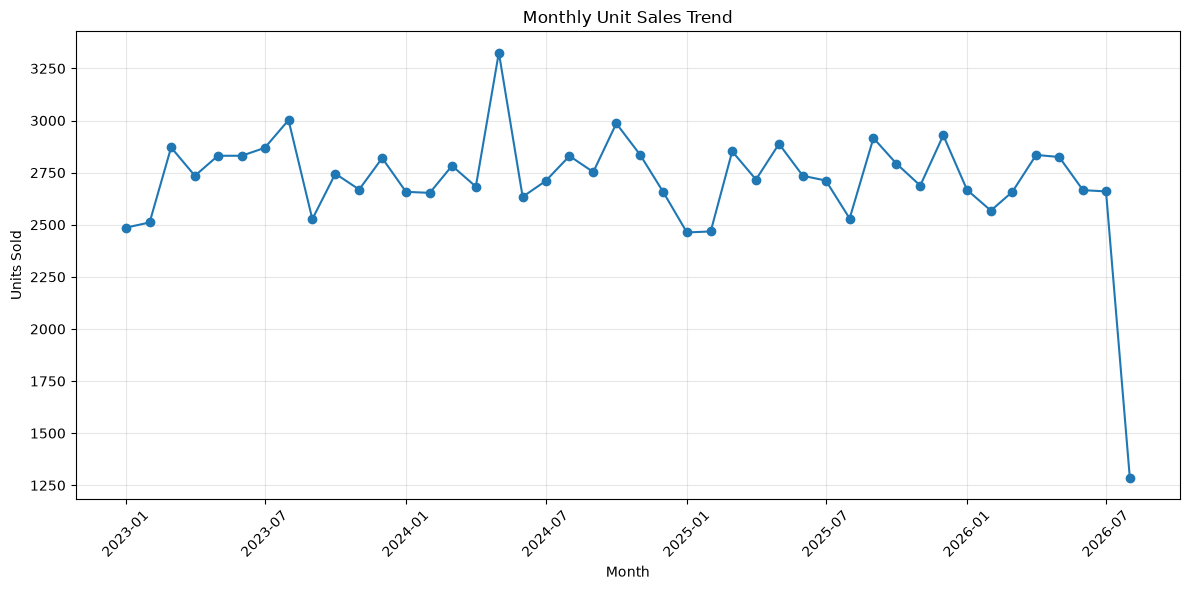

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['ds'],
    monthly_sales['units_sold'],
    marker='o'
)

plt.title('Monthly Unit Sales Trend')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
## Creating historical sales dataset
historical_sales = monthly_sales.copy()

## making ds datetime
historical_sales['ds'] = pd.to_datetime(historical_sales['ds'])

## calculating average unit sales by calendar month
monthly_avg = (
    historical_sales
    .assign(month=historical_sales['ds'].dt.month)
    .groupby('month')['units_sold']
    .mean()
)

monthly_avg

month
1     2568.500000
2     2550.000000
3     2791.000000
4     2742.500000
5     2967.500000
6     2716.500000
7     2737.750000
8     2412.250000
9     2732.000000
10    2841.333333
11    2731.000000
12    2802.333333
Name: units_sold, dtype: float64

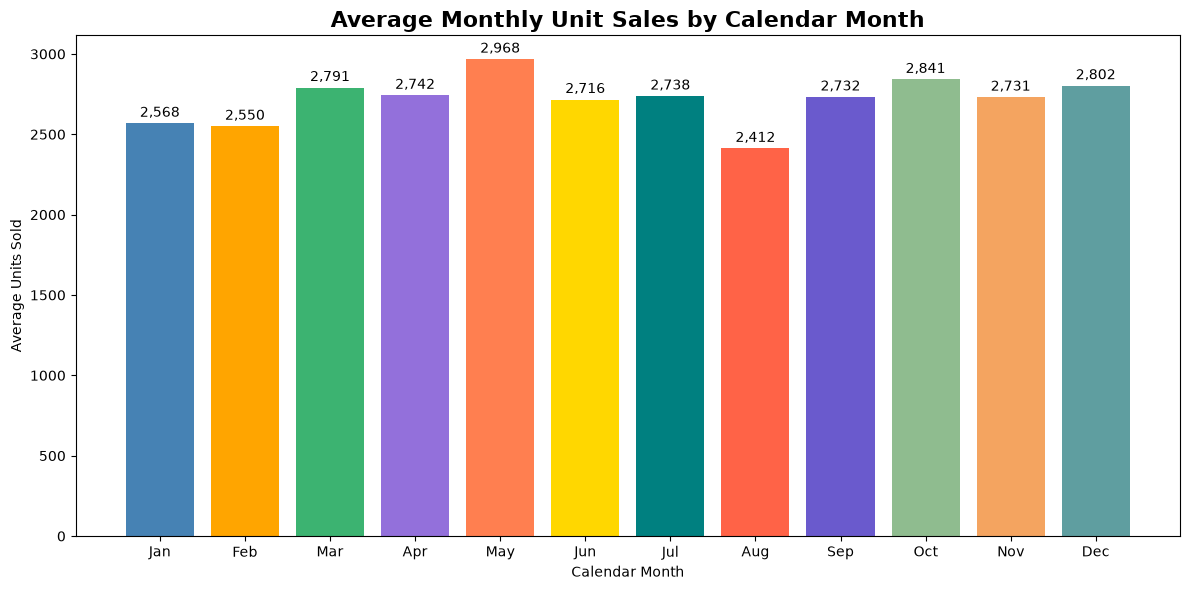

In [15]:
import matplotlib.pyplot as plt

monthly_avg = (
    historical_sales
    .assign(month=historical_sales['ds'].dt.month)
    .groupby('month')['units_sold']
    .mean()
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    monthly_avg.index,
    monthly_avg.values,
    color=[
        'steelblue', 'orange', 'mediumseagreen',
        'mediumpurple', 'coral', 'gold',
        'teal', 'tomato', 'slateblue',
        'darkseagreen', 'sandybrown', 'cadetblue'
    ]
)

plt.title(
    'Average Monthly Unit Sales by Calendar Month',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Calendar Month')
plt.ylabel('Average Units Sold')

plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        f'{value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Key EDA Findings 

The EDA findings show that the average monthly unit sales vary across the calendar year, with May showing the 
highest average demand at approximately 2,968 units and February showing the lowest at approximately 2,550 units. The variation across months indicates that seasonal patterns may influence demand. This supports the use of month_number as a feature in the forecasting models.

# 6. Feature Engineering

To capture historical demand patterns and seasonality, we created additional time-based, lag, and rolling-window features from the monthly unit sales data.

The features were designed to provide the model with information about calendar seasonality, recent sales activity, and longer-term trends.

#### Feature Created

FEATURE			  DESCRIPTION 

 YEAR:	          Calendar year of the observation 
 
MONTH_NUMBER:	  Calendar month used to capture seasonal patterns

UNITS_LAG_1:	  Units sold in the previous month 

UNITS_LAG_3:	  Units sold three months earlier 

UNITS_LAG_6:	  Units sold six months earlier 

UNITS_LAG_12:	  Units sold twelve months earlier 

ROLLING_3M_UNITS:  Average units sold over the previous three months 

ROLLING_6M_UNITS:  Average units sold over the previous six months 

ROLLING_12M_UNITS: Average units sold over the previous twelve months 

Lag features capture historical demand at different time intervals, while rolling averages smooth short-term fluctuations and provide the model with information about recent and longer-term demand trends.

The rolling features were calculated using shifted values so that only information available before the prediction month was used, preventing future data leakage.


In [16]:
sales_ml = monthly_sales.copy()

sales_ml['year'] = sales_ml['ds'].dt.year
sales_ml['month_number'] = sales_ml['ds'].dt.month

## Lag features
sales_ml['units_lag_1'] = sales_ml['units_sold'].shift(1)
sales_ml['units_lag_3'] = sales_ml['units_sold'].shift(3)
sales_ml['units_lag_6'] = sales_ml['units_sold'].shift(6)
sales_ml['units_lag_12'] = sales_ml['units_sold'].shift(12)

## Rolling averages
sales_ml['rolling_3m_units'] = (
    sales_ml['units_sold']
    .shift(1)
    .rolling(3)
    .mean()
)

sales_ml['rolling_6m_units'] = (
    sales_ml['units_sold']
    .shift(1)
    .rolling(6)
    .mean()
)

sales_ml['rolling_12m_units'] = (
    sales_ml['units_sold']
    .shift(1)
    .rolling(12)
    .mean()
)

In [17]:
sales_ml[
    [ 
        'ds', 'units_sold', 'year', 'month_number', 'units_lag_1', 'units_lag_3', 'units_lag_6', 'units_lag_12', 'rolling_3m_units',
        'rolling_6m_units', 'rolling_12m_units'
    ]
].tail(10)

,ds,units_sold,year,month_number,units_lag_1,units_lag_3,units_lag_6,units_lag_12,rolling_3m_units,rolling_6m_units,rolling_12m_units
33,2025-11-01,2688.0,2025,11,2793.0,2530.0,2888.0,2836.0,2746.333333,2762.333333,2714.000000
26,2025-12-01,2929.0,2025,12,2688.0,2916.0,2735.0,2658.0,2799.000000,2729.000000,2701.666667
39,2026-01-01,2667.0,2026,1,2929.0,2793.0,2712.0,2463.0,2803.333333,2761.333333,2724.250000
38,2026-02-01,2568.0,2026,2,2667.0,2688.0,2530.0,2468.0,2761.333333,2753.833333,2741.250000
42,2026-03-01,2658.0,2026,3,2568.0,2929.0,2916.0,2852.0,2721.333333,2760.166667,2749.583333
36,2026-04-01,2835.0,2026,4,2658.0,2667.0,2793.0,2717.0,2631.000000,2717.166667,2733.416667
43,2026-05-01,2825.0,2026,5,2835.0,2568.0,2688.0,2888.0,2687.000000,2724.166667,2743.250000
41,2026-06-01,2666.0,2026,6,2825.0,2658.0,2929.0,2735.0,2772.666667,2747.000000,2738.000000
40,2026-07-01,2660.0,2026,7,2666.0,2835.0,2667.0,2712.0,2775.333333,2703.166667,2732.250000
37,2026-08-01,1287.0,2026,8,2660.0,2825.0,2568.0,2530.0,2717.000000,2702.000000,2727.916667


## 7. Train-Validation Split

A chronological train-validation split was used to evaluate the forecasting models while preserving the natural order of the time series. Randomly 
splitting the data could allow future observations to influence the training data and lead to data leakage.

The models were trained on historical monthly unit sales from January 2023 through December 2025 and validated on completed monthly sales from January 2026 through July 2026.

August 2026 was excluded from validation because it represents a partial month. After model validation, the final XGBoost model was used to forecast August through December 2026.

In [18]:
### Train / Validation Split

train_ml = sales_ml[
    sales_ml['ds'] <= '2025-12-01'
].copy()

test_ml = sales_ml[
    (sales_ml['ds'] >= '2026-01-01') &
    (sales_ml['ds'] <= '2026-07-01')
].copy()

print("Training period:")
print(train_ml['ds'].min(), "to", train_ml['ds'].max())

print("\nValidation period:")
print(test_ml['ds'].min(), "to", test_ml['ds'].max())

print("\nTraining rows:", len(train_ml))
print("Validation rows:", len(test_ml))

Training period:
2023-01-01 00:00:00 to 2025-12-01 00:00:00

Validation period:
2026-01-01 00:00:00 to 2026-07-01 00:00:00

Training rows: 36
Validation rows: 7


In [19]:
### Feature split

features = [
    'year',
    'month_number',
    'units_lag_1',
    'units_lag_3',
    'units_lag_6',
    'units_lag_12',
    'rolling_3m_units',
    'rolling_6m_units',
    'rolling_12m_units'
]

train_ml = train_ml.dropna(subset=features).copy()

test_ml = test_ml.dropna(subset=features).copy()

X_train = train_ml[features]
y_train = train_ml['units_sold']

X_test = test_ml[features]
y_test = test_ml['units_sold']

print("Training rows:", len(X_train))
print("Validation rows:", len(X_test))
print("Validation months:")
print(test_ml['ds'].tolist())

Training rows: 24
Validation rows: 7
Validation months:
[Timestamp('2026-01-01 00:00:00'), Timestamp('2026-02-01 00:00:00'), Timestamp('2026-03-01 00:00:00'), Timestamp('2026-04-01 00:00:00'), Timestamp('2026-05-01 00:00:00'), Timestamp('2026-06-01 00:00:00'), Timestamp('2026-07-01 00:00:00')]


#### Train/ split Summary Table

In [20]:
split_summary = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Future Forecast'],
    'Period': [
        'Jan 2023 - Dec 2025',
        'Jan 2026 - Jul 2026',
        'Aug 2026 - Dec 2026'
    ],
    'Purpose': [
        'Model Training',
        'Model Evaluation',
        'Future Prediction'
    ]
})

display(split_summary)

,Dataset,Period,Purpose
0,Training,Jan 2023 - Dec 2025,Model Training
1,Validation,Jan 2026 - Jul 2026,Model Evaluation
2,Future Forecast,Aug 2026 - Dec 2026,Future Prediction


## Running Model Comparison
## 8. Naive Baseline Model

A naive baseline model was established to provide a simple benchmark for evaluating the performance of the machine-learning forecasting models.

The baseline predicts future monthly unit sales using the previous month's actual unit sales. This approach assumes that the most recent observed demand is a reasonable estimate of the next month's demand.

The baseline was evaluated on the same January–July 2026 validation period used for the other models. Performance was measured using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_predictions = test_ml['units_lag_1']

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_mape = np.mean(
    np.abs(
        (y_test - baseline_predictions) / y_test
    )
) * 100

print(f"Sales Baseline MAE: ${baseline_mae:,.2f}")
print(f"Sales Baseline RMSE: ${baseline_rmse:,.2f}")
print(f"Sales Baseline MAPE: {baseline_mape:,.2f}%")

Sales Baseline MAE: $114.71
Sales Baseline RMSE: $143.07
Sales Baseline MAPE: 4.26%


In [22]:
baseline_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'Value': [
        f'${baseline_mae:,.2f}',
        f'${baseline_rmse:,.2f}',
        f'{baseline_mape:.2f}%'
    ]
})

display(baseline_results)

,Metric,Value
0,MAE,$114.71
1,RMSE,$143.07
2,MAPE,4.26%


### Baseline Result

The baseline model achieved a MAPE of 4.26% on the validation period. This benchmark provides a reference point for determining whether more advanced models can improve forecasting accuracy.

## 9. Linear Regression Model

Linear Regression was developed as a simple machine-learning benchmark to evaluate whether relationships between historical sales features and monthly unit sales could improve upon the naive baseline model.

The model uses calendar, lag, and rolling-average features to predict monthly unit sales. The model was trained using the January 2023–December 2025 training period and evaluated on the January–July 2026 validation period.

Performance was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [23]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_mape = np.mean(
    np.abs(
        (y_test - linear_predictions) / y_test
    )
) * 100

print(f"Linear Regression MAE: ${linear_mae:,.2f}")
print(f"Linear Regression RMSE: ${linear_rmse:,.2f}")
print(f"Linear Regression MAPE: {linear_mape:.2f}%")

Linear Regression MAE: $312.24
Linear Regression RMSE: $327.28
Linear Regression MAPE: 11.58%


In [24]:
## Result Table

linear_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'Value': [
        f'${linear_mae:,.2f}',
        f'${linear_rmse:,.2f}',
        f'{linear_mape:.2f}%'
    ]
})

display(linear_results)

,Metric,Value
0,MAE,$312.24
1,RMSE,$327.28
2,MAPE,11.58%


#### Linear Regression Result

Linear Regression achieved a MAPE of 11.58% on the validation period. This performance was weaker than the baseline model, indicating that a simple 
linear relationship between the engineered features and unit sales was not sufficient to capture the underlying demand patterns in this dataset.

## 10. Prophet

Prophet was evaluated as a dedicated time-series forecasting model for monthly unit sales. Unlike the machine-learning models, Prophet models the time series directly by learning patterns such as trend and seasonality.

The model was trained on historical monthly unit sales through December 2025 and evaluated on the January–July 2026 validation period.

Prophet predictions were compared with the actual validation values using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

In [26]:
!pip install prophet

  Using cached prophet-1.4.0-py3-none-win_amd64.whl.metadata (3.7 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.103-py3-none-any.whl.metadata (55 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.4.0-py3-none-win_amd64.whl (12.1 MB)
Using cached holidays-0.103-py3-none-any.whl (1.6 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)

   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   ---------- ----------------------------- 1/4 [holidays]
   -------------------- ------------------- 2/4 [cmdstanpy]
   ------------------------------ ---------

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

In [28]:
monthly_sales = monthly_sales.sort_values("ds").copy()

train = monthly_sales[
    (monthly_sales["ds"] >= "2023-01-01") &
    (monthly_sales["ds"] <= "2025-12-01")
].copy()

validation = monthly_sales[
    (monthly_sales["ds"] >= "2026-01-01") &
    (monthly_sales["ds"] <= "2026-07-01")
].copy()

prophet_train = train[["ds", "units_sold"]].rename(
    columns={"units_sold": "y"}
)

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_train)

future = validation[["ds"]].copy()

forecast = model.predict(future)

results = validation[["ds", "units_sold"]].copy()

results["prophet_prediction"] = forecast["yhat"].values

mae = mean_absolute_error(
    results["units_sold"],
    results["prophet_prediction"]
)

rmse = np.sqrt(
    mean_squared_error(
        results["units_sold"],
        results["prophet_prediction"]
    )
)

mape = np.mean(
    np.abs(
        (results["units_sold"] - results["prophet_prediction"])
        / results["units_sold"]
    )
) * 100


print(f"Prophet MAE: {mae:,.2f} units")
print(f"Prophet RMSE: {rmse:,.2f} units")
print(f"Prophet MAPE: {mape:.2f}%")

# Save Prophet metrics 
prophet_mae = mae
prophet_rmse = rmse
prophet_mape = mape

print("\nValidation Predictions:")

display(results)


11:49:53 - cmdstanpy - INFO - Chain [1] start processing
11:49:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 118.48 units
Prophet RMSE: 125.79 units
Prophet MAPE: 4.39%

Validation Predictions:


,ds,units_sold,prophet_prediction
39,2026-01-01,2667.0,2490.861406
38,2026-02-01,2568.0,2507.220203
42,2026-03-01,2658.0,2819.578914
36,2026-04-01,2835.0,2693.479940
43,2026-05-01,2825.0,2893.086269
41,2026-06-01,2666.0,2756.544838
40,2026-07-01,2660.0,2790.693145


In [29]:
prophet_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'Value': [
        f'${linear_mae:,.2f}',
        f'${linear_rmse:,.2f}',
        f'{linear_mape:.2f}%'
    ]
})

display(prophet_results)

,Metric,Value
0,MAE,$312.24
1,RMSE,$327.28
2,MAPE,11.58%


### Prophet Result

Prophet achieved a MAPE of 4.39% on the January–July 2026 validation period. Its performance was comparable to the baseline model but did not provide a meaningful improvement in MAPE. XGBoost achieved substantially lower validation error and was selected as the final forecasting model.

## 11. XGBoost

XGBoost was evaluated as a nonlinear machine-learning approach for predicting monthly unit sales. The model was trained using historical sales patterns, calendar information, lag features, and rolling-average features.

Unlike Linear Regression, XGBoost can capture nonlinear relationships and interactions between the engineered features.

The model was trained on the January 2023–December 2025 period and evaluated on the January–July 2026 validation period using MAE, RMSE, and MAPE.

In [30]:
!pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)


In [31]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = 'reg:squarederror',
    random_state = 42
)

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:
## Model Evaluation

xgb_predictions = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_mape = np.mean(
    np.abs(
        (y_test - xgb_predictions) / y_test
    )
) * 100

print(f"XGBoost MAE: ${xgb_mae:,.2f} units")
print(f"XGBoost RMSE: ${xgb_rmse:,.2f} units")
print(f"XGBoost MAPE: {xgb_mape:.2f}%")

XGBoost MAE: $57.46 units
XGBoost RMSE: $71.13 units
XGBoost MAPE: 2.14%


## Actual vs Predicted Chart.

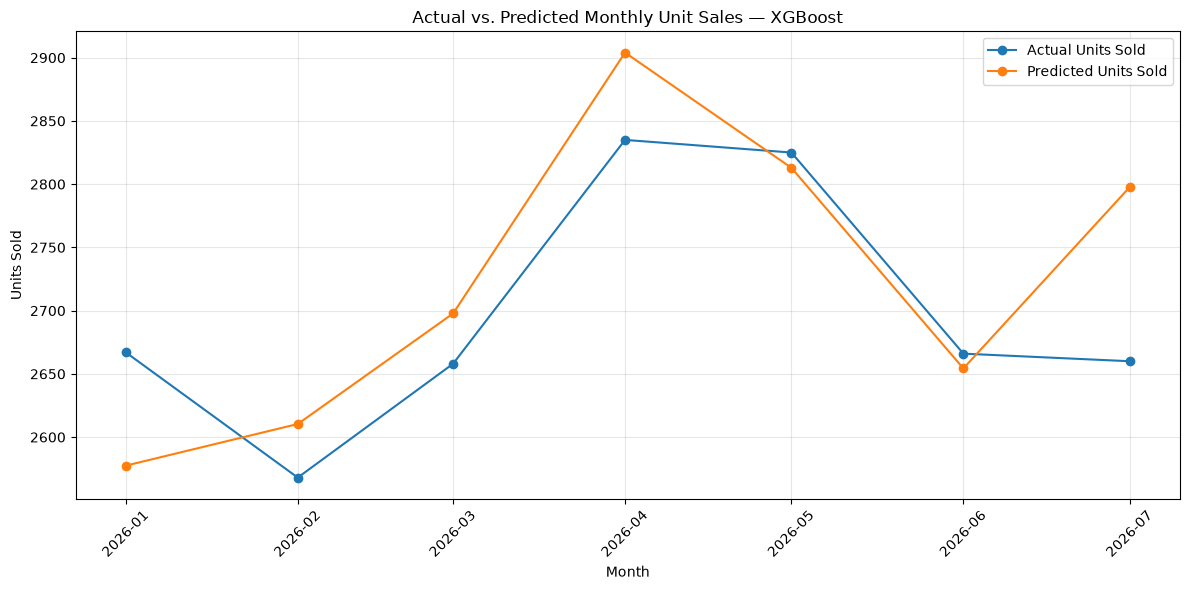

In [33]:
# Getting the dates corresponding to the test set

test_dates = monthly_sales.loc[X_test.index, 'ds']

plt.figure(figsize=(12, 6))

plt.plot(
    test_dates,
    y_test.values,
    marker='o',
    label='Actual Units Sold'
)

plt.plot(
    test_dates,
    xgb_predictions,
    marker='o',
    label='Predicted Units Sold'
)

plt.title('Actual vs. Predicted Monthly Unit Sales — XGBoost')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    'images/actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Validation Predictions

In [34]:
xgb_validation = pd.DataFrame({
    'ds': test_ml['ds'].values,
    'actual_units': y_test.values,
    'xgboost_prediction': xgb_predictions
})

display(xgb_validation)

,ds,actual_units,xgboost_prediction
0,2026-01-01,2667.0,2577.460693
1,2026-02-01,2568.0,2610.364258
2,2026-03-01,2658.0,2697.759766
3,2026-04-01,2835.0,2904.037109
4,2026-05-01,2825.0,2812.912842
5,2026-06-01,2666.0,2654.308838
6,2026-07-01,2660.0,2797.762695


### XGBoost Results 

XGBoost achieved the best validation performance among the evaluated models, with an MAE of 57.46 units, RMSE of 71.13 units, and MAPE of 2.14%.

The model outperformed the baseline, Linear Regression, and Prophet models across the primary evaluation metrics. Based on its superior validation 
performance, XGBoost was selected as the final model for forecasting future monthly unit sales.

# 12. Model Performance Comparison

The four forecasting approaches were evaluated using the same January–July 2026 validation period and the same target variable, 'units_sold'.

The Model performance was compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). Lower values indicate better forecasting performance.

XGBoost achieved the lowest error across all three evaluation metrics and was selected as the final forecasting model.

In [35]:
performance_comparison = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Prophet',
        'XGBoost'
    ],
    'MAE': [
        baseline_mae,
        linear_mae,
        prophet_mae,
        xgb_mae
    ],
    'RMSE': [
        baseline_rmse,
        linear_rmse,
        prophet_rmse,
        xgb_rmse
    ],
    'MAPE (%)': [
        baseline_mape,
        linear_mape,
        prophet_mape,
        xgb_mape
    ]
})

performance_comparison = performance_comparison.round({
    'MAE': 2,
    'RMSE': 2,
    'MAPE (%)': 2
})

display(performance_comparison)

,Model,MAE,RMSE,MAPE (%)
0,Baseline,114.71,143.07,4.26
1,Linear Regression,312.24,327.28,11.58
2,Prophet,118.48,125.79,4.39
3,XGBoost,57.46,71.13,2.14


### Performance Chart

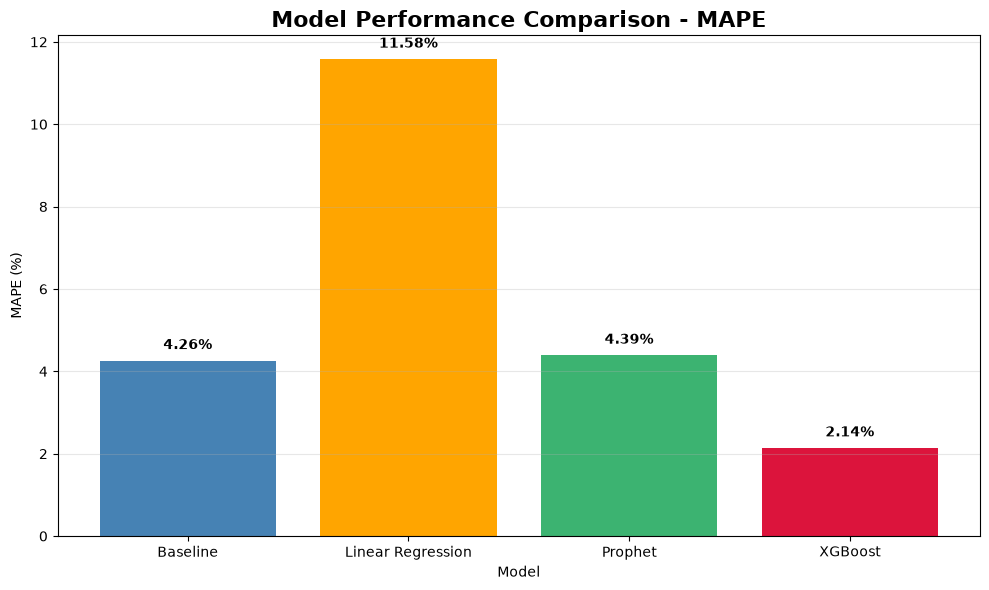

In [36]:
import matplotlib.pyplot as plt

models = performance_comparison['Model']
mape_values = performance_comparison['MAPE (%)']

plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    mape_values,
    color=[
        'steelblue',
        'orange',
        'mediumseagreen',
        'crimson'
    ]
)

plt.title(
    'Model Performance Comparison - MAPE',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Model')
plt.ylabel('MAPE (%)')

for bar, value in zip(bars, mape_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 13. XGBoost Feature Importance

Feature importance was analyzed to understand which variables contributed most to the XGBoost model's predictions of monthly unit sales.

The results show that recent historical demand and seasonal patterns were the most influential factors. Rolling averages capture recent and longer-term sales trends, while 'month_number' captures potential seasonal patterns.

In [37]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=True
)

display(
    feature_importance.sort_values(
        'importance',
        ascending=False
    )
)

,feature,importance
6,rolling_3m_units,0.210674
1,month_number,0.150876
7,rolling_6m_units,0.147382
8,rolling_12m_units,0.123830
5,units_lag_12,0.113620
2,units_lag_1,0.073560
4,units_lag_6,0.069387
3,units_lag_3,0.065066
0,year,0.045607


#### Feature Importance Chart

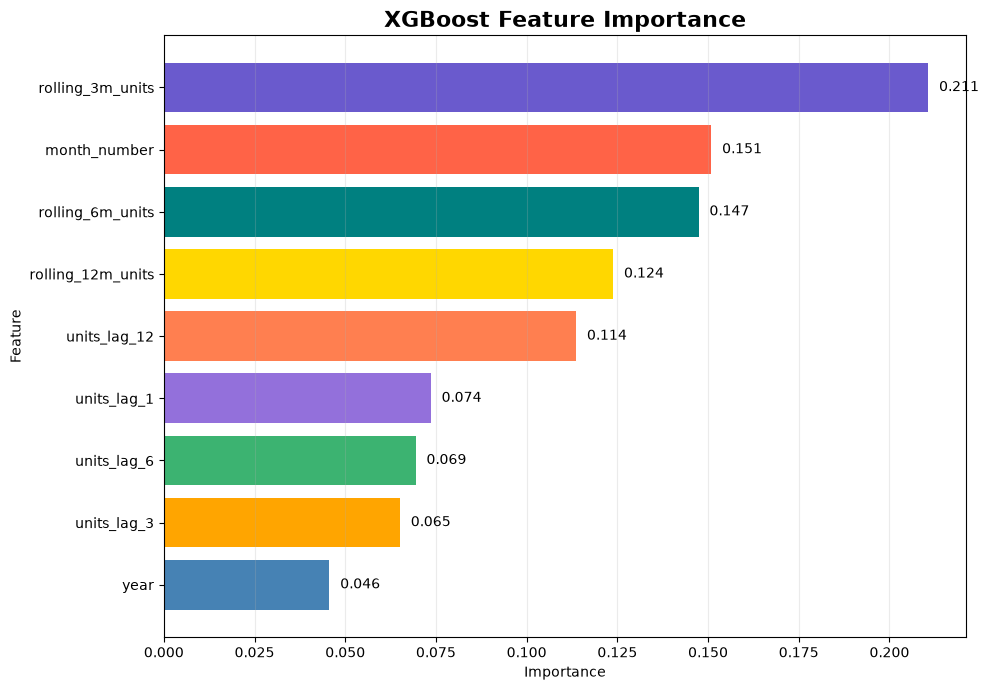

In [38]:
plt.figure(figsize=(10, 7))

colors = [
    'steelblue', 'orange', 'mediumseagreen', 'mediumpurple', 'coral', 'gold', 'teal', 'tomato', 'slateblue'
]

bars = plt.barh(
    feature_importance['feature'],
    feature_importance['importance'],
    color=colors
)

plt.title(
    'XGBoost Feature Importance',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center'
    )

plt.grid(
    axis='x',
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Feature Importance Findings

The most influential feature was rolling_3m_units, with an importance of 21.07%, indicating that recent three-month demand patterns were highly useful for predicting monthly unit sales.

The month_number was the second most important feature at 15.09%, suggesting that calendar seasonality also contributed to the model's predictions. The six-month and twelve-month rolling averages were also important, demonstrating that both recent and longer-term demand patterns helped the model forecast future sales.

These results support the use of historical demand and seasonal features in the final XGBoost forecasting model.

## 14. Future Forecast

The XGBoost model was selected as the final forecasting model based on its superior validation performance, achieving a MAPE of 2.14%.

The final model was used to forecast monthly unit sales for August through December 2026. These predictions provide an estimate of expected demand for the upcoming months and can support inventory planning, resource allocation, and sales planning.

In [39]:
### Creating forecast_data from historica_sales
forecast_data = historical_sales.copy()

## formatting columns
forecast_data['ds'] = pd.to_datetime(forecast_data['ds'])

## selecting columns needed for forecast
forecast_data = forecast_data[['ds', 'units_sold']].copy()

## sorting by date
forecast_data = forecast_data.sort_values('ds').reset_index(drop=True)

forecast_data.head()

,ds,units_sold
0,2023-01-01,2486.0
1,2023-02-01,2511.0
2,2023-03-01,2871.0
3,2023-04-01,2735.0
4,2023-05-01,2831.0


In [40]:
# Future forecast dates
future_dates = pd.date_range(
    start='2026-08-01',
    end='2026-12-01',
    freq='MS')
    
future_predictions = []

for date in future_dates:

    new_row = pd.DataFrame({'ds': [date]})
    new_row['year'] = date.year
    new_row['month_number'] = date.month

    temp = pd.concat([forecast_data, new_row], ignore_index=True)

    temp['units_lag_1'] = temp['units_sold'].shift(1)
    temp['units_lag_3'] = temp['units_sold'].shift(3)
    temp['units_lag_6'] = temp['units_sold'].shift(6)
    temp['units_lag_12'] = temp['units_sold'].shift(12)

    temp['rolling_3m_units'] = temp['units_sold'].shift(1).rolling(3).mean()
    temp['rolling_6m_units'] = temp['units_sold'].shift(1).rolling(6).mean()
    temp['rolling_12m_units'] = temp['units_sold'].shift(1).rolling(12).mean()

    prediction_row = temp.iloc[-1]

    X_future = prediction_row[features].to_frame().T
    X_future = X_future.apply(pd.to_numeric, errors='coerce')

    prediction = xgb_model.predict(X_future)[0]

    future_predictions.append({
        'ds': date,
        'predicted_units': prediction
    })

    forecast_data = pd.concat([
        forecast_data,
        pd.DataFrame({'ds': [date], 'units_sold': [prediction]})
    ], ignore_index=True)


In [41]:
future_forecast = pd.DataFrame(future_predictions)

future_forecast['predicted_units'] = (
    future_forecast['predicted_units']
    .round(0)
    .astype(int)
)

display(future_forecast)

,ds,predicted_units
0,2026-08-01,2910
1,2026-09-01,2775
2,2026-10-01,2843
3,2026-11-01,2747
4,2026-12-01,2843


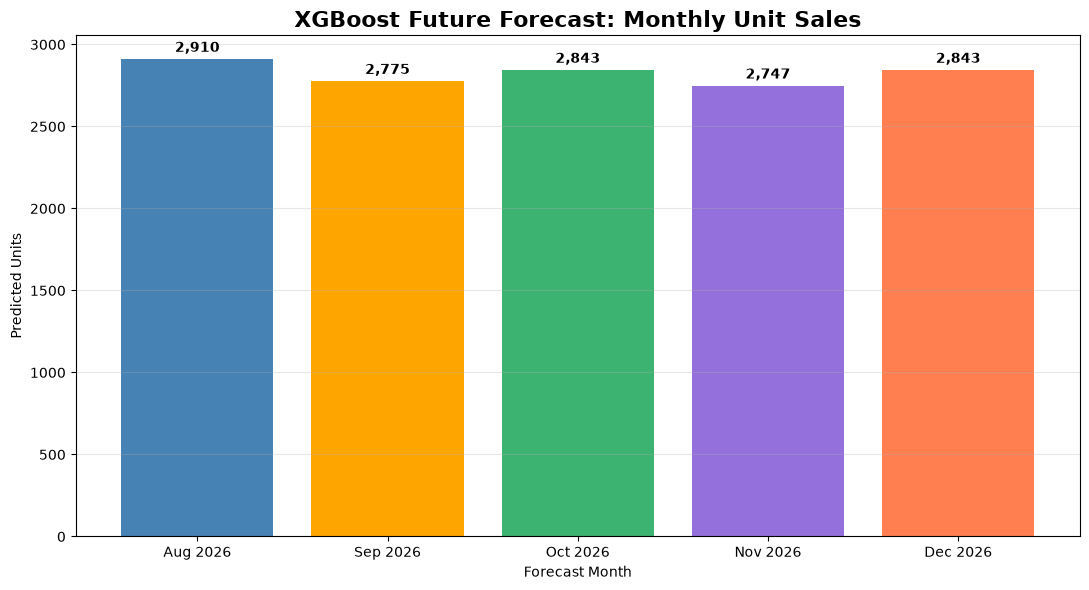

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

colors = [
    'steelblue', 'orange', 'mediumseagreen', 'mediumpurple', 'coral'
]

bars = plt.bar(
    future_forecast['ds'].dt.strftime('%b %Y'),
    future_forecast['predicted_units'],
    color=colors
)

plt.title(
    'XGBoost Future Forecast: Monthly Unit Sales',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Forecast Month')
plt.ylabel('Predicted Units')

# Add values above each bar
for bar, value in zip(
    bars,
    future_forecast['predicted_units']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 25,
        f'{value:,}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 15. Business Insights

### 1. Stable future demand

The XGBoost model forecasts monthly unit sales between approximately 2,738 and 2,834 units from August through December 2026. Overall demand is expected to remain relatively stable during the forecast period.

### 2. Recent demand is the strongest predictor
The feature importance analysis shows that 'rolling_3m_units' was the most important feature, accounting for approximately 21.1% of the model's feature 
importance. This indicates that recent sales patterns provide valuable information for predicting near-term demand.

### 3. Seasonal patterns influence demand

The 'month_number' was the second most important feature at approximately 15.1%. The EDA also showed differences in average unit sales across calendar months, suggesting that seasonal patterns should be considered when planning inventory and sales activities.

### 4. XGBoost provided the best forecasting performance

XGBoost achieved a MAPE of 2.14%, outperforming the Baseline (4.26%), Prophet (4.39%), and Linear Regression (11.58%). This represents approximately a 49.8% reduction in MAPE compared with the baseline model.

### 5. Inventory and operational planning

The forecast provides a data-driven demand baseline that can support inventory replenishment, procurement, staffing, and operational planning. Expected demand of approximately 2,700–2,800 units per month can help the business prepare for anticipated demand while monitoring actual sales as new data becomes available.

## 16. Conclusion

This project developed a monthly unit-sales forecasting solution using historical sales data from January 2023 through July 2026. Data preparation and KPI calculations were performed in MySQL Workbench, followed by exploratory data analysis, feature engineering, and machine-learning modeling in Python.

Four forecasting approaches were evaluated: Baseline, Linear Regression, Prophet, and XGBoost. XGBoost achieved the best validation performance, with an MAE of 57.46 units, RMSE of 71.13 units, and MAPE of 2.14%.

Based on its superior validation performance, XGBoost was selected as the final forecasting model. The model forecasts relatively stable monthly demand of approximately 2,738–2,834 units from August through December 2026.

Overall, the project demonstrates how SQL-based data preparation, exploratory analysis, feature engineering, and machine-learning forecasting can be combined to generate actionable insights for inventory, procurement, and operational planning.